## Step 1: Install and imports

In [1]:
!pip install -q torch pandas numpy scikit-learn matplotlib seaborn

## Step 2: Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from google.colab import files

## Step 3: Upload CSVs

Upload `cnn_embeddings_daily.csv` and `bge_embeddings_daily.csv`

In [4]:
uploaded = files.upload()

cnn_df = pd.read_csv("cnn_embeddings_daily.csv")
bge_df = pd.read_csv("bge_embeddings_daily.csv")

print("CNN shape:", cnn_df.shape)
print("BGE shape:", bge_df.shape)
print("Dates match:", (cnn_df["date"].values == bge_df["date"].values).all())

Saving bge_embeddings_daily.csv to bge_embeddings_daily.csv
CNN shape: (2642, 259)
BGE shape: (2642, 1027)
Dates match: True


## Step 4: Remap labels and prepare data

In [5]:
# Remap labels: 5 -> 3 classes
LABEL_MAP = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
cnn_df["label"] = cnn_df["label"].map(LABEL_MAP)

print("Remapped label distribution:")
print(cnn_df["label"].value_counts().sort_index())

CNN_DIM = 256
BGE_DIM = 1024

cnn_emb_cols = [f"emb_{i}" for i in range(CNN_DIM)]
bge_emb_cols = [f"bge_{i}" for i in range(BGE_DIM)]

# Merge on date
merged = cnn_df[["date", "split", "label"] + cnn_emb_cols].copy()
merged = merged.merge(
    bge_df[["date"] + bge_emb_cols],
    on="date", how="inner"
)
merged["date"] = pd.to_datetime(merged["date"])
merged = merged.sort_values("date").reset_index(drop=True)

print(f"Merged shape: {merged.shape}")
print(f"Total dims: CNN {CNN_DIM} + BGE {BGE_DIM} = {CNN_DIM + BGE_DIM}")

Remapped label distribution:
label
0    703
1    956
2    983
Name: count, dtype: int64
Merged shape: (2642, 1283)
Total dims: CNN 256 + BGE 1024 = 1280


## Step 5: Normalise embeddings

In [6]:
train_mask = merged["split"] == "train"
test_mask  = merged["split"] == "test"

scaler_cnn = StandardScaler()
scaler_bge = StandardScaler()

merged.loc[train_mask, cnn_emb_cols] = scaler_cnn.fit_transform(merged.loc[train_mask, cnn_emb_cols])
merged.loc[test_mask,  cnn_emb_cols] = scaler_cnn.transform(merged.loc[test_mask,  cnn_emb_cols])

merged.loc[train_mask, bge_emb_cols] = scaler_bge.fit_transform(merged.loc[train_mask, bge_emb_cols])
merged.loc[test_mask,  bge_emb_cols] = scaler_bge.transform(merged.loc[test_mask,  bge_emb_cols])

print("Embeddings normalised.")

Embeddings normalised.


## Step 6: Build sequences

30 consecutive days of CNN embeddings as sequence + BGE embedding of last day as context.

In [7]:
SEQ_LEN = 30

train_df = merged[merged["split"] == "train"].sort_values("date").reset_index(drop=True)
test_df  = merged[merged["split"] == "test"].sort_values("date").reset_index(drop=True)

def build_sequences(df, seq_len):
    X_cnn, X_bge, y = [], [], []
    for i in range(len(df) - seq_len + 1):
        window = df.iloc[i:i+seq_len]
        X_cnn.append(window[cnn_emb_cols].values)       # (30, 256)
        X_bge.append(window[bge_emb_cols].values[-1])   # last day BGE (1024,)
        y.append(window["label"].values[-1])
    return (
        np.array(X_cnn, dtype=np.float32),
        np.array(X_bge, dtype=np.float32),
        np.array(y,     dtype=np.int64)
    )

X_cnn_train, X_bge_train, y_train = build_sequences(train_df, SEQ_LEN)
X_cnn_test,  X_bge_test,  y_test  = build_sequences(test_df,  SEQ_LEN)

print(f"Train: CNN {X_cnn_train.shape}  BGE {X_bge_train.shape}  Labels {y_train.shape}")
print(f"Test : CNN {X_cnn_test.shape}   BGE {X_bge_test.shape}   Labels {y_test.shape}")

Train: CNN (1886, 30, 256)  BGE (1886, 1024)  Labels (1886,)
Test : CNN (698, 30, 256)   BGE (698, 1024)   Labels (698,)


## Step 7: Dataset and DataLoader

In [8]:
class SeqFusionDataset(Dataset):
    def __init__(self, X_cnn, X_bge, y):
        self.X_cnn = torch.tensor(X_cnn)
        self.X_bge = torch.tensor(X_bge)
        self.y     = torch.tensor(y)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X_cnn[idx], self.X_bge[idx], self.y[idx]

train_ds = SeqFusionDataset(X_cnn_train, X_bge_train, y_train)
test_ds  = SeqFusionDataset(X_cnn_test,  X_bge_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Train: {len(train_ds)}  |  Test: {len(test_ds)}")

Train: 1886  |  Test: 698


## Step 8: Cross-attention fusion model

- CNN sequence (30 days × 256-dim) → self-attention over days
- BGE daily embedding (1024-dim) → projected to 256-dim → Key + Value
- Cross-attention: each CNN day queries BGE context
- Last token → classifier → 3 classes

In [9]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, cnn_dim=256, bge_dim=1024, hidden_dim=256,
                 num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()

        self.bge_proj = nn.Sequential(
            nn.Linear(bge_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        self.cnn_proj  = nn.Linear(cnn_dim, hidden_dim)
        self.pos_enc   = nn.Embedding(100, hidden_dim)

        self.self_attn = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout, batch_first=True
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, cnn_seq, bge_vec):
        B, T, _ = cnn_seq.shape
        cnn_h   = self.cnn_proj(cnn_seq)
        positions = torch.arange(T, device=cnn_seq.device).unsqueeze(0)
        cnn_h   = cnn_h + self.pos_enc(positions)
        cnn_h   = self.self_attn(cnn_h)
        bge_h   = self.bge_proj(bge_vec).unsqueeze(1)
        fused, _ = self.cross_attn(query=cnn_h, key=bge_h, value=bge_h)
        fused   = self.norm(fused + cnn_h)
        out     = fused[:, -1, :]
        return self.classifier(out)

## Step 9: Training

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

label_counts = np.bincount(y_train)
class_weights = torch.tensor(
    1.0 / label_counts * label_counts.sum() / len(label_counts),
    dtype=torch.float32
).to(device)
print("Class weights:", class_weights.cpu().numpy().round(3))

model     = CrossAttentionFusion().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS, PATIENCE = 100, 15
best_val_acc, patience_ctr, best_state = 0.0, 0, None
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for cnn_b, bge_b, labels in train_loader:
        cnn_b, bge_b, labels = cnn_b.to(device), bge_b.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(cnn_b, bge_b)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for cnn_b, bge_b, labels in test_loader:
            cnn_b, bge_b, labels = cnn_b.to(device), bge_b.to(device), labels.to(device)
            logits = model(cnn_b, bge_b)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)

    acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    val_accs.append(acc)

    if acc > best_val_acc:
        best_val_acc = acc
        patience_ctr = 0
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {train_losses[-1]:.4f} | Val Acc: {acc:.4f} | Best: {best_val_acc:.4f} | Patience: {patience_ctr}/{PATIENCE}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best val acc: {best_val_acc:.4f}")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model (val acc: {best_val_acc:.4f})")

Device: cuda
Class weights: [1.088 0.95  0.973]
Epoch  10 | Loss: 0.1909 | Val Acc: 0.8653 | Best: 0.8926 | Patience: 2/15
Epoch  20 | Loss: 0.1661 | Val Acc: 0.8840 | Best: 0.9054 | Patience: 6/15

Early stopping at epoch 29. Best val acc: 0.9054

Restored best model (val acc: 0.9054)


## Step 10: Evaluate

=== BGE Cross-Attention Fusion ===
              precision    recall  f1-score   support

   No Stress       0.85      0.94      0.89       125
    Moderate       0.97      0.80      0.88       283
      Severe       0.88      1.00      0.93       290

    accuracy                           0.91       698
   macro avg       0.90      0.91      0.90       698
weighted avg       0.91      0.91      0.90       698



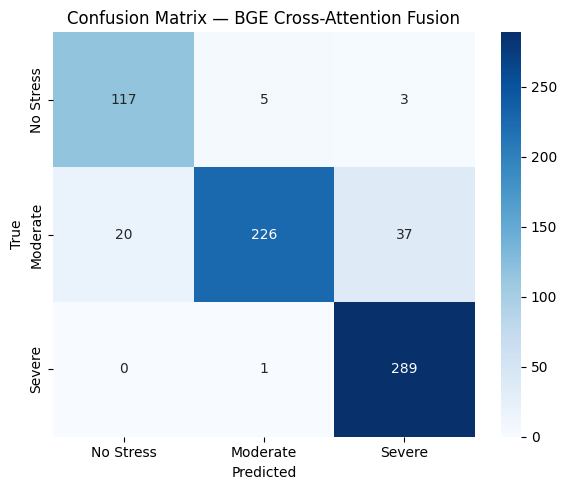

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for cnn_b, bge_b, labels in test_loader:
        cnn_b, bge_b = cnn_b.to(device), bge_b.to(device)
        logits = model(cnn_b, bge_b)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("=== BGE Cross-Attention Fusion ===")
print(classification_report(all_labels, all_preds,
      target_names=["No Stress", "Moderate", "Severe"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Stress","Moderate","Severe"],
            yticklabels=["No Stress","Moderate","Severe"])
plt.title("Confusion Matrix — BGE Cross-Attention Fusion")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_bge.png", dpi=150)
plt.show()

## Step 11: Training curves

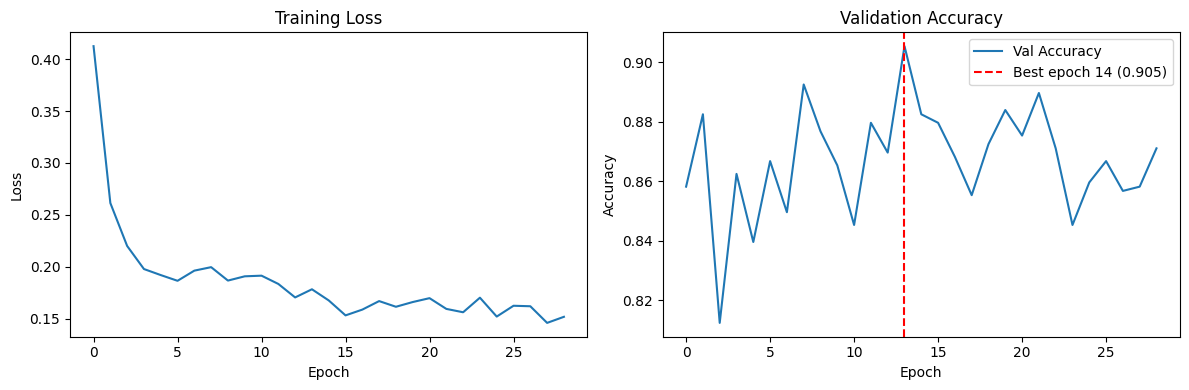

Best epoch: 14  |  Best val acc: 0.9054


In [12]:
best_epoch = int(np.argmax(val_accs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(val_accs, label="Val Accuracy")
ax2.axvline(best_epoch, color="red", linestyle="--",
            label=f"Best epoch {best_epoch+1} ({best_val_acc:.3f})")
ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/training_curves_bge.png", dpi=150)
plt.show()
print(f"Best epoch: {best_epoch+1}  |  Best val acc: {best_val_acc:.4f}")

## Step 12: Save and download

In [13]:
torch.save(model.state_dict(), "/content/bge_crossattn_fusion.pth")

from google.colab import files as colab_files
colab_files.download("/content/bge_crossattn_fusion.pth")
colab_files.download("/content/confusion_matrix_bge.png")
colab_files.download("/content/training_curves_bge.png")
print("Done.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
